<a href="https://colab.research.google.com/github/FARAHEltem/sleep-quality-classification/blob/main/comparaison_modeles_sommeil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 😴 Classification de la qualité du sommeil : comparaison de modèles

Ce notebook compare trois modèles (**régression logistique**, **Random Forest**, **SVM**) pour prédire si une personne a une **bonne** (note ≥ 7) ou une **mauvaise** qualité de sommeil.

**Rigueur méthodologique.** Dans la première version (rapport R), la formule `Quality_Binary ~ .` utilisait toutes les colonnes, y compris `Quality of Sleep`, la note à partir de laquelle la cible est construite (fuite de données), ainsi que l'identifiant `Person ID`. Ici, ces colonnes sont **retirées**. On vérifie aussi l'effet des **lignes en double** du dataset (section 6).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

SEED = 123

## 1. Chargement des données
Le fichier est lu directement depuis le dépôt GitHub : rien à envoyer dans Colab.

In [2]:
URL = "https://raw.githubusercontent.com/FARAHEltem/sleep-quality-classification/main/Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(URL)
print(df.shape)
df.head()

(374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2. Préparation
- Cible binaire : `Good` (1) si la note est ≥ 7, sinon `Bad` (0)
- Tension artérielle séparée en deux variables numériques
- Harmonisation de la catégorie d'IMC
- **Retrait de `Quality of Sleep` et `Person ID`** (fuite de données et identifiant sans valeur prédictive)
- `Occupation` est écartée : 11 professions pour 374 personnes, avec des groupes très petits

In [3]:
data = df.copy()
data["Quality_Binary"] = (data["Quality of Sleep"] >= 7).astype(int)
data["Sleep Disorder"] = data["Sleep Disorder"].fillna("None")
data["BMI Category"] = data["BMI Category"].replace({"Normal Weight": "Normal"})
tension = data["Blood Pressure"].str.split("/", expand=True).astype(int)
data["Systolic"], data["Diastolic"] = tension[0], tension[1]

NUM = ["Age", "Sleep Duration", "Physical Activity Level", "Stress Level",
       "Heart Rate", "Daily Steps", "Systolic", "Diastolic"]
CAT = ["Gender", "BMI Category", "Sleep Disorder"]

X = data[NUM + CAT]          # Quality of Sleep et Person ID ne sont PAS dans X
y = data["Quality_Binary"]
print(y.value_counts().rename({1: "Good", 0: "Bad"}))

Quality_Binary
Good    257
Bad     117
Name: count, dtype: int64


## 3. Découpage stratifié 80 / 20

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Entraînement :", X_train.shape[0], "| Test :", X_test.shape[0])

Entraînement : 299 | Test : 75


## 4. Modèles
Chaque modèle est intégré dans un pipeline (standardisation + encodage), ce qui évite toute fuite d'information du test vers l'entraînement. Les classes sont pondérées (`class_weight="balanced"`) car la répartition est 68 / 32.

In [5]:
prep = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])

modeles = {
    "Régression logistique": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=SEED),
    "SVM (noyau RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
}

pipelines, lignes = {}, []
for nom, modele in modeles.items():
    pipe = Pipeline([("prep", prep), ("model", modele)]).fit(X_train, y_train)
    pipelines[nom] = pipe
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    lignes.append({
        "Modèle": nom,
        "Accuracy": accuracy_score(y_test, pred),
        "Sensibilité": recall_score(y_test, pred),
        "Spécificité": recall_score(y_test, pred, pos_label=0),
        "Précision": precision_score(y_test, pred),
        "F1-score": f1_score(y_test, pred),
        "AUC": roc_auc_score(y_test, proba),
    })

resultats = pd.DataFrame(lignes).set_index("Modèle")
resultats.round(4)

,Accuracy,Sensibilité,Spécificité,Précision,F1-score,AUC
Modèle,,,,,,
Régression logistique,0.9867,0.9808,1.0,1.0,0.9903,0.9975
Random Forest,0.9867,0.9808,1.0,1.0,0.9903,0.9992
SVM (noyau RBF),0.9867,0.9808,1.0,1.0,0.9903,0.9849


## 5. Validation croisée (5 plis)
Un seul découpage de 75 individus de test est fragile : la validation croisée donne une estimation plus fiable.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_lignes = []
for nom, modele in modeles.items():
    pipe = Pipeline([("prep", prep), ("model", modele)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=["accuracy", "f1", "roc_auc"])
    cv_lignes.append({
        "Modèle": nom,
        "Accuracy (moy. ± écart-type)": f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
        "F1-score": f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}",
        "AUC": f"{scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f}",
    })
pd.DataFrame(cv_lignes).set_index("Modèle")

,Accuracy (moy. ± écart-type),F1-score,AUC
Modèle,,,
Régression logistique,0.984 ± 0.016,0.988 ± 0.012,0.999 ± 0.001
Random Forest,0.995 ± 0.007,0.996 ± 0.005,1.000 ± 0.000
SVM (noyau RBF),0.992 ± 0.007,0.994 ± 0.005,0.997 ± 0.005


## 6. Matrices de confusion et courbes ROC

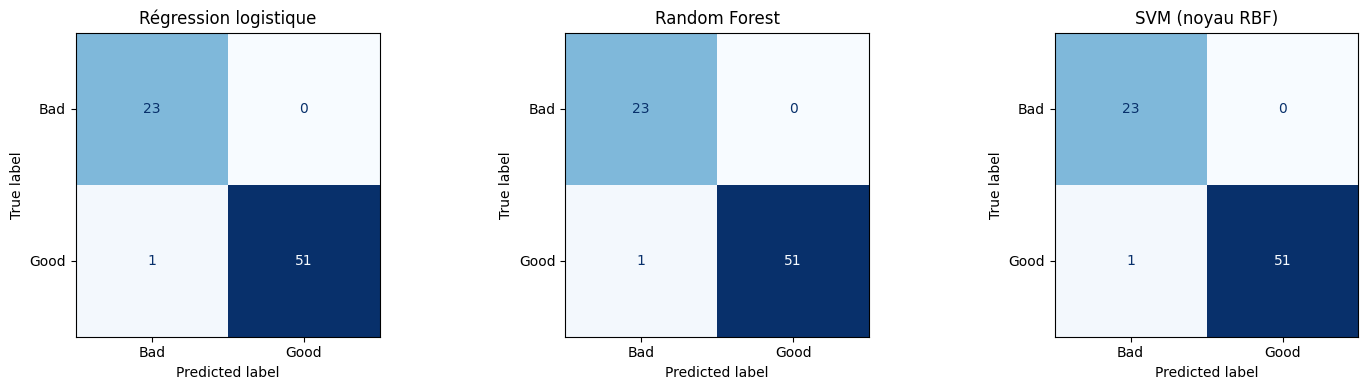

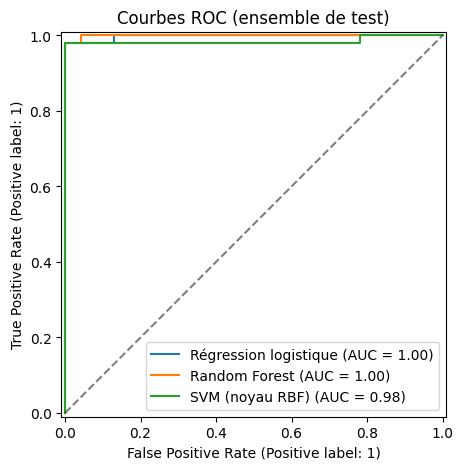

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nom, pipe) in zip(axes, pipelines.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, display_labels=["Bad", "Good"],
                                          ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nom)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
for nom, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=nom, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_title("Courbes ROC (ensemble de test)")
plt.show()

## 7. Importance des variables (Random Forest)

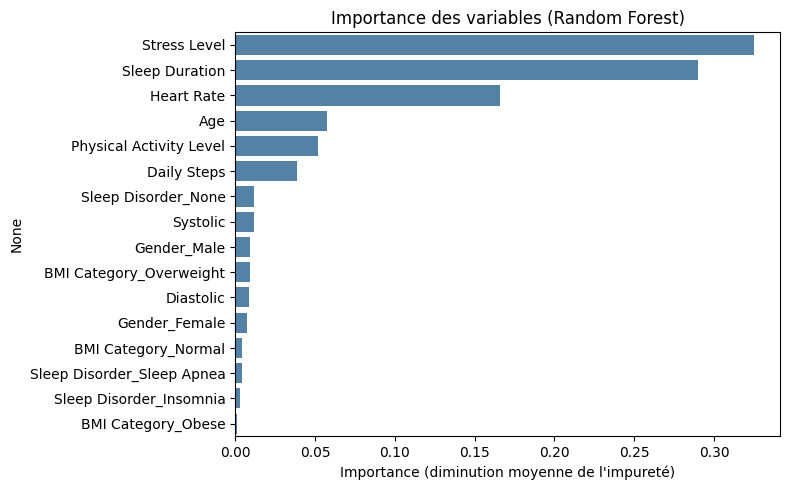

,0
Stress Level,0.325
Sleep Duration,0.290
Heart Rate,0.166
Age,0.058
Physical Activity Level,0.052
Daily Steps,0.039
Sleep Disorder_None,0.012
Systolic,0.012
Gender_Male,0.009
BMI Category_Overweight,0.009


In [8]:
rf = pipelines["Random Forest"]
noms = rf.named_steps["prep"].get_feature_names_out()
noms = [n.split("__", 1)[1] for n in noms]
importance = (pd.Series(rf.named_steps["model"].feature_importances_, index=noms)
              .sort_values(ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index, color="steelblue")
plt.title("Importance des variables (Random Forest)")
plt.xlabel("Importance (diminution moyenne de l'impureté)")
plt.tight_layout()
plt.show()
importance.round(3)

## 8. Contrôle de robustesse : doublons et variables clés
Le dataset contient beaucoup de **profils identiques** (même âge, même stress, même durée de sommeil…). Si un même profil se retrouve à la fois en entraînement et en test, le score peut être optimiste. On refait donc une validation croisée **groupée** : un profil donné est entièrement soit en entraînement, soit en test.

In [9]:
profils = data[NUM + CAT].astype(str).agg("|".join, axis=1)
print("Lignes :", len(data), "| profils uniques :", profils.nunique())

cv_groupe = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
pipe_lr = Pipeline([("prep", prep), ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
s = cross_validate(pipe_lr, X, y, cv=cv_groupe, groups=profils, scoring=["accuracy", "roc_auc"])
print(f"Régression logistique, CV groupée : accuracy {s['test_accuracy'].mean():.3f} ± {s['test_accuracy'].std():.3f}, "
      f"AUC {s['test_roc_auc'].mean():.3f}")

# Avec seulement deux variables : stress et durée de sommeil
pipe_2 = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
s2 = cross_validate(pipe_2, X[["Stress Level", "Sleep Duration"]], y, cv=cv_groupe, groups=profils, scoring=["accuracy"])
print(f"Stress + durée de sommeil seulement : accuracy {s2['test_accuracy'].mean():.3f}")

Lignes : 374 | profils uniques : 130
Régression logistique, CV groupée : accuracy 0.977 ± 0.022, AUC 1.000
Stress + durée de sommeil seulement : accuracy 0.977


**Lecture :** même en évitant les doublons, et même avec **seulement deux variables** (stress et durée de sommeil), l'accuracy reste autour de 98 %. Les performances très élevées viennent donc surtout de la **nature synthétique** des données, dont les classes sont presque parfaitement séparables par ces deux variables.

## 9. Interprétation de la régression logistique : odds ratios
Les variables numériques étant **standardisées**, chaque odds ratio indique l'effet d'une augmentation d'**un écart-type**. Comme les classes sont presque parfaitement séparables, un modèle logistique non régularisé (glm, statsmodels) donnerait des coefficients infinis et des p-values inutilisables : on utilise donc les coefficients du modèle régularisé de scikit-learn.

In [10]:
lr = pipelines["Régression logistique"]
noms_lr = [n.split("__", 1)[1] for n in lr.named_steps["prep"].get_feature_names_out()]
coefs = pd.Series(lr.named_steps["model"].coef_[0], index=noms_lr)
odds = pd.DataFrame({"Coefficient": coefs, "Odds ratio": np.exp(coefs)}).sort_values("Coefficient")
odds.round(3)

,Coefficient,Odds ratio
Stress Level,-2.436,0.088
Heart Rate,-1.041,0.353
Gender_Male,-0.853,0.426
Sleep Disorder_Sleep Apnea,-0.528,0.590
BMI Category_Overweight,-0.472,0.624
Daily Steps,-0.333,0.716
Diastolic,-0.055,0.946
Systolic,0.032,1.033
BMI Category_Normal,0.067,1.070
Sleep Disorder_Insomnia,0.116,1.123


## 10. Conclusion

- Les trois modèles atteignent environ **98 %** d'accuracy, **sans** la variable `Quality of Sleep`, et le résultat tient en validation croisée groupée (sans doublons entre entraînement et test).
- Le **niveau de stress** (effet négatif) et la **durée de sommeil** (effet positif) sont les facteurs dominants : à eux deux, ils suffisent presque à séparer les classes.
- Ces scores très élevés reflètent la **nature synthétique** du dataset ; sur des données cliniques réelles, les performances seraient vraisemblablement plus modestes.